Upload Content Image


Saving Screenshot (246).png to Screenshot (246).png
Upload Style Image


Saving wikiimages-art-74050_1920.jpg to wikiimages-art-74050_1920 (1).jpg


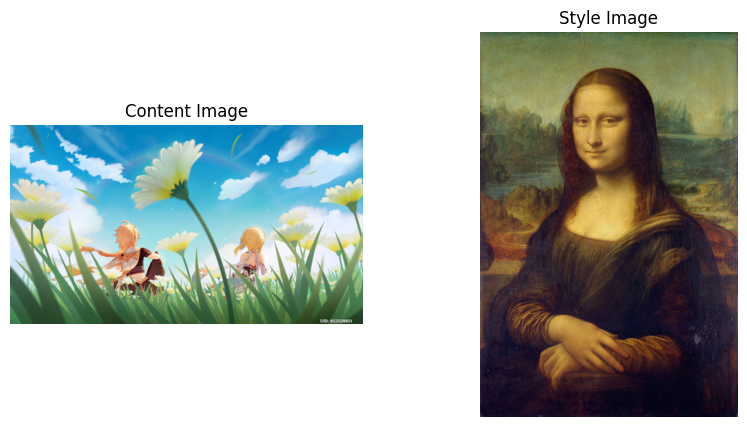

Step: 50
Step: 100
Step: 150
Step: 200
Step: 250
Step: 300
Step: 350
Step: 400
Step: 450
Step: 500
Step: 550
Step: 600
Step: 650
Step: 700
Step: 750
Step: 800
Step: 850
Step: 900
Step: 950
Step: 1000


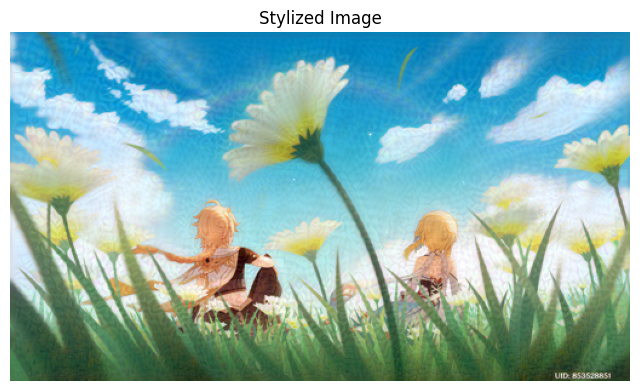

In [4]:
# ===============================
# Neural Style Transfer using VGG19
# ===============================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import PIL.Image
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input

# -----------------------------
# Upload Images
# -----------------------------

from google.colab import files

print("Upload Content Image")
content_upload = files.upload()

print("Upload Style Image")
style_upload = files.upload()

content_path = list(content_upload.keys())[0]
style_path = list(style_upload.keys())[0]


# -----------------------------
# Load and preprocess images
# -----------------------------

def load_image(path, max_dim=512):

    img = PIL.Image.open(path)

    long = max(img.size)
    scale = max_dim / long

    img = img.resize(
        (round(img.size[0]*scale), round(img.size[1]*scale))
    )

    img = np.array(img)

    img = np.expand_dims(img, axis=0)

    return tf.convert_to_tensor(img, dtype=tf.float32)


content_image = load_image(content_path)
style_image = load_image(style_path)


# -----------------------------
# Display images
# -----------------------------

def imshow(image, title=None):
    image = tf.squeeze(image, axis=0)
    image = tf.cast(image, tf.uint8)
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis('off')


plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
imshow(content_image, "Content Image")

plt.subplot(1,2,2)
imshow(style_image, "Style Image")

plt.show()


# -----------------------------
# Load VGG19 Model
# -----------------------------

vgg = VGG19(include_top=False, weights='imagenet')
vgg.trainable = False


# -----------------------------
# Define Style and Content Layers
# -----------------------------

content_layers = ['block5_conv2']

style_layers = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1',
    'block5_conv1'
]

num_content_layers = len(content_layers)
num_style_layers = len(style_layers)


# -----------------------------
# Extract features from layers
# -----------------------------

def vgg_layers(layer_names):

    outputs = [vgg.get_layer(name).output for name in layer_names]

    model = tf.keras.Model([vgg.input], outputs)

    return model


feature_extractor = vgg_layers(style_layers + content_layers)


# -----------------------------
# Gram Matrix for Style
# -----------------------------

def gram_matrix(input_tensor):

    result = tf.linalg.einsum('bijc,bijd->bcd', input_tensor, input_tensor)

    input_shape = tf.shape(input_tensor)

    num_locations = tf.cast(input_shape[1]*input_shape[2], tf.float32)

    return result / num_locations


# -----------------------------
# Style Content Model
# -----------------------------

class StyleContentModel(tf.keras.models.Model):

    def __init__(self, style_layers, content_layers):
        super(StyleContentModel, self).__init__()

        self.vgg = vgg_layers(style_layers + content_layers)
        self.style_layers = style_layers
        self.content_layers = content_layers
        self.num_style_layers = len(style_layers)

        self.vgg.trainable = False


    def call(self, inputs):

        inputs = preprocess_input(inputs)

        outputs = self.vgg(inputs)

        style_outputs = outputs[:self.num_style_layers]
        content_outputs = outputs[self.num_style_layers:]

        style_outputs = [gram_matrix(style_output)
                         for style_output in style_outputs]

        content_dict = {
            content_name: value
            for content_name, value
            in zip(self.content_layers, content_outputs)
        }

        style_dict = {
            style_name: value
            for style_name, value
            in zip(self.style_layers, style_outputs)
        }

        return {'content': content_dict, 'style': style_dict}


# -----------------------------
# Create model
# -----------------------------

extractor = StyleContentModel(style_layers, content_layers)

style_targets = extractor(style_image)['style']
content_targets = extractor(content_image)['content']


# -----------------------------
# Initialize generated image
# -----------------------------

generated_image = tf.Variable(content_image)


# -----------------------------
# Define Loss Functions
# -----------------------------

style_weight = 1e-2
content_weight = 1e4


def style_content_loss(outputs):

    style_outputs = outputs['style']
    content_outputs = outputs['content']

    style_loss = tf.add_n([
        tf.reduce_mean((style_outputs[name] - style_targets[name])**2)
        for name in style_outputs.keys()
    ])

    style_loss *= style_weight / num_style_layers

    content_loss = tf.add_n([
        tf.reduce_mean((content_outputs[name] - content_targets[name])**2)
        for name in content_outputs.keys()
    ])

    content_loss *= content_weight / num_content_layers

    loss = style_loss + content_loss

    return loss


# -----------------------------
# Optimizer
# -----------------------------

optimizer = tf.keras.optimizers.Adam(learning_rate=0.02)


# -----------------------------
# Training Step
# -----------------------------

@tf.function()
def train_step(image):

    with tf.GradientTape() as tape:

        outputs = extractor(image)

        loss = style_content_loss(outputs)

    grad = tape.gradient(loss, image)

    optimizer.apply_gradients([(grad, image)])

    image.assign(tf.clip_by_value(image, 0.0, 255.0))


# -----------------------------
# Run Optimization
# -----------------------------

epochs = 10
steps_per_epoch = 100

step = 0

for n in range(epochs):

    for m in range(steps_per_epoch):

        step += 1

        train_step(generated_image)

        if step % 50 == 0:
            print("Step:", step)


# -----------------------------
# Show Final Stylized Image
# -----------------------------

plt.figure(figsize=(8,8))
imshow(generated_image, "Stylized Image")
plt.show()